
# Feedback-GRAPE trained policy check — literal training model

This notebook is meant to debug the case where a trained feedback-GRAPE policy should give high fidelity, but a check gives only a few percent.

The important change relative to the previous version is that the **exact-model section does not reimplement the Hamiltonian**. It literally reuses the same training-style functions:

- `build_drive_htree(...)`
- `hmat_from_htree(...)`
- `evol_hdt_exp(...)`
- `make_idle(...)`
- `measure_sz(...)`
- `make_trajectory(...)`

So the first check below should reproduce the training notebook, including all hidden toolbox conventions. Only after this literal check works should you trust any Dynamiqs translation.


In [1]:

# Run this notebook from a fresh kernel.
# Since we load weights.bin directly, we do not need Orbax and therefore avoid GPU sharding issues.
import os

USE_CPU_ONLY = True
if USE_CPU_ONLY:
    os.environ["JAX_PLATFORMS"] = "cpu"

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")


'platform'

In [2]:

from pathlib import Path
from functools import partial
import json
import struct
import warnings

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.scipy as jsp

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
from flax.core import freeze, unfreeze

from toolbox import *

print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("JAX devices:", jax.devices())

_REQUIRED_TOOLBOX_NAMES = [
    "basis", "identity", "destroy", "tensor", "hconj", "sigma",
    "setup_bspline_builder", "bknots_on_interval",
    "hmat_from_htree", "evol_hdt_exp",
]
missing = [name for name in _REQUIRED_TOOLBOX_NAMES if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required toolbox objects: {missing}")


jax 0.6.2
jaxlib 0.6.2
JAX devices: [CpuDevice(id=0)]


## Configuration, model folder, and parameters

In [3]:

def _strip_comment_keys(obj):
    if isinstance(obj, dict):
        return {k: _strip_comment_keys(v) for k, v in obj.items()
                if not (isinstance(k, str) and k.startswith("//"))}
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj


def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return _strip_comment_keys(data)

config_directory = Path("")
cfg = load_config_dict(config_directory, "configuration.json")

# This is the target used in the uploaded training notebook.
TARGET_FOCK_N = 2

# Choose the folder containing weights.bin.
# The first entry is the save_name in the uploaded training notebook.
# If it does not exist on your machine, the code falls back to the folders found in your diagnostic.
preferred_folders = [
    Path("trained_nn15_readout_decay_whole_readout_20bs_fock_2_target"),
    Path("trained_nn15_readout_decay_20bs_fock_2_target"),
    Path("trained_nn15_70_percent_readout_decay_20bs_fock_2_target"),
    Path("trained_nn15_30_percent_readout_decay_20bs_fock_2_target"),
    Path("trained_nn15_20bs_fock_2_target"),
    Path("trained_nn15_readout_decay_whole_readout_20bs_fock_target"),
]

available_folders = sorted(Path.cwd().glob("trained_nn15*"))
print("Available trained folders:")
for p in available_folders:
    print(f"  {p.name:70s}  weights.bin={(p / 'weights.bin').exists()}  ckpt={(p / '1').exists()}")

trained_folder = None
for p in preferred_folders:
    if (p / "weights.bin").exists():
        trained_folder = p
        break

if trained_folder is None:
    raise FileNotFoundError(
        "No preferred weights.bin folder found. Set trained_folder manually after inspecting the list above."
    )

print("\nUsing trained_folder:", trained_folder.resolve())
print("Target checked: Fock |{}>".format(TARGET_FOCK_N))
print("weights.bin exists:", (trained_folder / "weights.bin").exists())


Available trained folders:
  trained_nn15_20bs_fock_2_target                                         weights.bin=True  ckpt=True
  trained_nn15_30_percent_readout_decay_20bs_fock_2_target                weights.bin=True  ckpt=True
  trained_nn15_70_percent_readout_decay_20bs_fock_2_target                weights.bin=True  ckpt=True
  trained_nn15_readout_decay_20bs_cat_target                              weights.bin=True  ckpt=True
  trained_nn15_readout_decay_20bs_fock_2_target                           weights.bin=True  ckpt=True
  trained_nn15_readout_decay_whole_readout_20bs_fock_target               weights.bin=True  ckpt=True
  trained_nn15_readout_rotation_20bs_cat_target                           weights.bin=True  ckpt=True

Using trained_folder: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_20bs_fock_2_target
Target checked: Fock |2>
weights.bin exists: True


In [4]:

# Copied from the training notebook.
# Hamiltonian parameters are in rad/us.
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
qubit_anham = 2 * jnp.pi * cfg["anharmonicity_MHz"]
cavity_self_kerr = 2 * jnp.pi * cfg["self_Kerr_kHz"] * 1e-3

# Relaxation times in us.
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

mu_qub = 20.0
mu_cav = 20.0

k = 2
bspln_num = 20
skip_left = k
skip_right = k
n = bspln_num + skip_left + skip_right

delta_ns = 64
m = n - k
T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0
L_ns = (k + 1) * delta_ns

t_drive = T_us_hw
ndt_drive = 200
num_bspln = bspln_num

inp_shape = (1,)
osz = num_bspln * 4
rec_features = osz
dense_features = [int(osz * 2), int(osz * 3), int(osz * 2)]
learning_rate = 0.00015

# Keep this equal to the training notebook unless you knowingly trained with another truncation.
N_cav = 25

# Copied from training.
t_idle = 15

psi_target_cav = basis(N_cav, TARGET_FOCK_N)
psi_target_cav /= jnp.sqrt(hconj(psi_target_cav) @ psi_target_cav)

print("chi / 2pi =", float(chi / (2 * jnp.pi) * 1e3), "kHz")
print("T control =", T_us_hw, "us")
print("N_cav =", N_cav)
print("t_idle =", t_idle, "us")
print("RNN features =", rec_features, "dense =", dense_features)


chi / 2pi = -660.8313 kHz
T control = 1.408 us
N_cav = 25
t_idle = 15 us
RNN features = 80 dense = [160, 240, 160]


## Time grids and B-splines — copied from training

In [5]:

t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)

print("bsplns_mids shape:", bsplns_mids.shape)
print("bsplns_edges shape:", bsplns_edges.shape)
print("t_drive_intvs unique:", np.unique(np.asarray(t_drive_intvs))[:5])


bsplns_mids shape: (20, 200)
bsplns_edges shape: (20, 201)
t_drive_intvs unique: [0.0070399  0.00703996 0.00703999 0.00704    0.00704   ]


## Literal training Hamiltonian and drive

In [6]:

# IMPORTANT: This is copied from the training notebook.
# Do not replace this by a hand-written Hamiltonian while debugging.
# hmat_from_htree/evol_hdt_exp may contain conventions that are easy to miss.

def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_disp = (chi / 2) * n_phot @ (one - sigz)
    H_drift = H_disp

    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, jnp.conj(e_cav), 1, 1],
    ]
    return ht


def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)


def make_drive(N_cav, chi):
    def drive(rho_init, es_qub, es_cav, dts):
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            return uevol @ rho @ hconj(uevol), None

        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        return rho_fin

    return drive


## Control layout — copied from training

In [7]:

def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav


## Idle relaxation — copied from training

In [8]:

def qubit_ops():
    g = basis(2)       # |g> = index 0
    e = basis(2, 1)    # |e> = index 1

    Pg = g @ hconj(g)
    Pe = e @ hconj(e)

    sm = g @ hconj(e)  # |g><e|, relaxation operator
    sp = e @ hconj(g)  # |e><g|, excitation operator

    sz = Pg - Pe       # diag(+1, -1)

    return g, e, Pg, Pe, sm, sp, sz


def liouv_relax_channel(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l


def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel(c) for c in cs)
    return jsp.linalg.expm(l * t)


def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    g, e, Pg, Pe, sm, sp, sz = qubit_ops()

    sig_down = tensor(sm, identity(N_cav))
    sigz = tensor(sz, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))

    c_ops = [
        1 / jnp.sqrt(t1_qub) * sig_down,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a,
    ]

    return c_ops


def make_idle(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle

print("sigma.m =", sigma.m)


sigma.m = [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]


## Measurement/reset and fidelity — copied from training

In [9]:

def measure_sz(key, rho_init, chi=chi, t_feedback=0.42, readout_duration=1.6):
    # Copied from the training notebook.
    t_reset_delay = t_feedback + readout_duration * 0.7

    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real  # [p_ground, p_excited]
    outcome_indx = jax.random.choice(key, 2, p=probs)  # 0 -> ground, 1 -> excited
    prob = probs[outcome_indx]

    idx_mid = rho_init.shape[-1] // 2

    rho_fin_cav = jnp.where(
        outcome_indx == 0,
        rho_init[:idx_mid, :idx_mid],
        rho_init[idx_mid:, idx_mid:],
    )

    # If the qubit was measured excited, it stays excited during the finite delay
    # before the conditional reset pi-pulse is applied.
    n_diag = jnp.arange(idx_mid)
    phase_e = jnp.exp(-1j * chi * n_diag * t_reset_delay)
    rho_fin_cav_delayed = phase_e[:, None] * rho_fin_cav * jnp.conj(phase_e[None, :])
    rho_fin_cav = jnp.where(outcome_indx == 1, rho_fin_cav_delayed, rho_fin_cav)

    # Qubit reset to ground.
    rho_fin_qub = basis(2) @ hconj(basis(2))
    rho_fin = tensor(rho_fin_qub, rho_fin_cav)
    rho_fin /= jnp.trace(rho_fin)

    # RNN input convention:
    # ground -> +1, excited -> -1.
    outcome = 1 - 2 * outcome_indx

    return outcome, prob, rho_fin


def make_fidelity_cav(psi_target_cav):
    def fidelity_cav(rho):
        idx_mid = rho.shape[-1] // 2
        rho_cav = rho[:idx_mid, :idx_mid] + rho[idx_mid:, idx_mid:]
        return (hconj(psi_target_cav) @ rho_cav @ psi_target_cav)[0][0].real

    return fidelity_cav

fidelity_cav = make_fidelity_cav(psi_target_cav)


## RNN architecture and weights.bin loader

In [10]:

def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(features=rec_features)
    return gru_cell.initialize_carry(key, inp_shape)


def create_flax_state(key,
                      rec_features, dense_features,
                      inp_shape, learning_rate,
                      *, print_summary):

    class Model(nn.Module):
        @nn.compact
        def __call__(self, carry, x):
            gru_cell = nn.GRUCell(features=rec_features)
            carry, x = gru_cell(carry, x)

            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)

            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)

            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(learning_rate=learning_rate),
    )

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state


def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)


In [11]:

def read_feedback_grape_weights_bin(folder):
    path = Path(folder).expanduser().resolve() / "weights.bin"
    if not path.exists():
        raise FileNotFoundError(path)

    arrays = []
    with open(path, "rb") as f:
        magic = f.read(8)
        if magic != b"GRUCPP01":
            raise ValueError(f"Wrong weights.bin header: {magic}")

        n_arrays = struct.unpack("i", f.read(4))[0]
        for _ in range(n_arrays):
            ndim = struct.unpack("i", f.read(4))[0]
            shape = tuple(struct.unpack("i", f.read(4))[0] for _ in range(ndim))
            n_elem = int(np.prod(shape))
            arr = np.frombuffer(f.read(4 * n_elem), dtype=np.float32).reshape(shape).copy()
            arrays.append(arr)

    if len(arrays) != 17:
        raise ValueError(f"Expected 17 arrays, got {len(arrays)}")

    return arrays


def load_feedback_grape_weights_bin_into_flax_state(folder, flax_state):
    arrays = read_feedback_grape_weights_bin(folder)

    # Exact order copied from save_cpp_weights(...) in the training notebook.
    names = [
        ("GRUCell_0", "ir", "kernel"),
        ("GRUCell_0", "ir", "bias"),
        ("GRUCell_0", "hr", "kernel"),

        ("GRUCell_0", "iz", "kernel"),
        ("GRUCell_0", "iz", "bias"),
        ("GRUCell_0", "hz", "kernel"),

        ("GRUCell_0", "in", "kernel"),
        ("GRUCell_0", "in", "bias"),
        ("GRUCell_0", "hn", "kernel"),

        ("Dense_0", "kernel"),
        ("Dense_0", "bias"),

        ("Dense_1", "kernel"),
        ("Dense_1", "bias"),

        ("Dense_2", "kernel"),
        ("Dense_2", "bias"),

        ("Dense_3", "kernel"),
        ("Dense_3", "bias"),
    ]

    params = unfreeze(flax_state.params)

    print("Loading weights from:", Path(folder).resolve() / "weights.bin")
    for arr, name in zip(arrays, names):
        if len(name) == 3:
            a0, a1, a2 = name
            old = params[a0][a1][a2]
            expected_shape = old.shape
        else:
            a0, a1 = name
            old = params[a0][a1]
            expected_shape = old.shape

        if arr.shape != expected_shape:
            raise ValueError(
                f"Shape mismatch for {name}: weights.bin has {arr.shape}, model expects {expected_shape}."
            )

        new = jnp.asarray(arr, dtype=old.dtype)
        if len(name) == 3:
            params[a0][a1][a2] = new
        else:
            params[a0][a1] = new

        print(f"{name}: {arr.shape} OK")

    return flax_state.replace(params=freeze(params))


In [12]:

seed = 1234
key = jax.random.key(seed)
key, subkey = jax.random.split(key)

flax_state = create_flax_state(
    subkey,
    rec_features,
    dense_features,
    inp_shape,
    learning_rate,
    print_summary=False,
)

flax_state = load_feedback_grape_weights_bin_into_flax_state(trained_folder, flax_state)

# Quick NN sanity check.
key, subkey = jax.random.split(key)
carry0 = init_carry(subkey, rec_features, inp_shape)
carry1, ctrl0 = apply_nn(flax_state, flax_state.params, carry0, jnp.array([1.0]))
print("ctrl0 shape:", ctrl0.shape)
print("ctrl0 finite:", bool(jnp.all(jnp.isfinite(ctrl0))))
print("ctrl0 min/max:", float(jnp.min(ctrl0)), float(jnp.max(ctrl0)))


Loading weights from: /home/user/python_experiments/train_feedback_grape/trained_nn15_readout_decay_20bs_fock_2_target/weights.bin
('GRUCell_0', 'ir', 'kernel'): (1, 80) OK
('GRUCell_0', 'ir', 'bias'): (80,) OK
('GRUCell_0', 'hr', 'kernel'): (80, 80) OK
('GRUCell_0', 'iz', 'kernel'): (1, 80) OK
('GRUCell_0', 'iz', 'bias'): (80,) OK
('GRUCell_0', 'hz', 'kernel'): (80, 80) OK
('GRUCell_0', 'in', 'kernel'): (1, 80) OK
('GRUCell_0', 'in', 'bias'): (80,) OK
('GRUCell_0', 'hn', 'kernel'): (80, 80) OK
('Dense_0', 'kernel'): (80, 160) OK
('Dense_0', 'bias'): (160,) OK
('Dense_1', 'kernel'): (160, 240) OK
('Dense_1', 'bias'): (240,) OK
('Dense_2', 'kernel'): (240, 160) OK
('Dense_2', 'bias'): (160,) OK
('Dense_3', 'kernel'): (160, 80) OK
('Dense_3', 'bias'): (80,) OK
ctrl0 shape: (4, 20)
ctrl0 finite: True
ctrl0 min/max: -0.24724997580051422 0.3143465518951416


## Literal training trajectory functions

In [13]:

def make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    fidelity_cav_local = make_fidelity_cav(psi_target_cav)
    idle_local = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive_local = make_drive(N_cav, chi)

    def time_step(key, rho, flax_state, params, carry):
        meas_out, prob, rho = measure_sz(key, rho)
        fid = fidelity_cav_local(rho)
        rho = idle_local(rho)
        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive_local(rho, es_qub, es_cav, t_drive_intvs)
        return rho, carry, fid, meas_out, prob

    return time_step


def make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    time_step = make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)

    def trajectory(key, flax_state, params, num_time_steps):
        def f(scan_carry, _):
            key, rho, carry = scan_carry
            key, subkey = jax.random.split(key)
            rho, carry, fid, meas_out, prob = time_step(subkey, rho, flax_state, params, carry)
            y = fid, meas_out, prob
            scan_carry = key, rho, carry
            return scan_carry, y

        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        psi_init = tensor(basis(2), psi_target_cav)
        scan_carry = key2, psi_init @ hconj(psi_init), carry
        _, ys = jax.lax.scan(f, scan_carry, length=num_time_steps)
        return ys

    return trajectory


def make_test_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):

    trajectory = make_trajectory(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )

    trajectory_vec = jax.vmap(
        trajectory, in_axes=(0, None, None, None)
    )

    @jax.jit
    def test_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        traj_out = trajectory_vec(keys, flax_state, flax_state.params, num_time_steps)
        return traj_out

    return test_on_batch


## Sanity checks before running trajectories

In [14]:

psi_init_check = tensor(basis(2), psi_target_cav)
rho_init_check = psi_init_check @ hconj(psi_init_check)

idx_mid = rho_init_check.shape[-1] // 2
p_g_init = jnp.trace(rho_init_check[:idx_mid, :idx_mid]).real
p_e_init = jnp.trace(rho_init_check[idx_mid:, idx_mid:]).real

print("initial p_g =", float(p_g_init))
print("initial p_e =", float(p_e_init))
print("initial target fidelity =", float(fidelity_cav(rho_init_check)))

key, subkey = jax.random.split(key)
meas_out0, prob0, rho_after_meas0 = measure_sz(subkey, rho_init_check)
print("measurement from initial state: meas_out =", float(meas_out0), "prob =", float(prob0))
print("fidelity after measurement =", float(fidelity_cav(rho_after_meas0)))

assert np.isclose(float(p_g_init), 1.0, atol=1e-6)
assert np.isclose(float(p_e_init), 0.0, atol=1e-6)
assert np.isclose(float(fidelity_cav(rho_init_check)), 1.0, atol=1e-6)


initial p_g = 1.0
initial p_e = 0.0
initial target fidelity = 1.0
measurement from initial state: meas_out = 1.0 prob = 1.0
fidelity after measurement = 1.0


## Exact reproduction of the training test

In [15]:

# These match the training notebook defaults.
num_time_steps_test = 150
batch_size_test = 32

test_on_batch = make_test_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle,
    psi_target_cav,
    batch_size_test,
    num_time_steps_test,
)

key, subkey = jax.random.split(key)
fids, meas_outs, probs = test_on_batch(subkey, flax_state)

print("fids shape:", fids.shape)
print("mean fidelity over all traj/steps =", float(fids.mean()))
print("mean fidelity over last half      =", float(fids[:, num_time_steps_test // 2:].mean()))
print("final fidelity mean/std          =", float(fids[:, -1].mean()), float(fids[:, -1].std()))
print("first step fidelity mean         =", float(fids[:, 0].mean()))
print("last 10 step fidelity mean       =", float(fids[:, -10:].mean()))


fids shape: (32, 150)
mean fidelity over all traj/steps = 0.7077663540840149
mean fidelity over last half      = 0.7027199268341064
final fidelity mean/std          = 0.764419674873352 0.30862346291542053
first step fidelity mean         = 1.0
last 10 step fidelity mean       = 0.7109136581420898


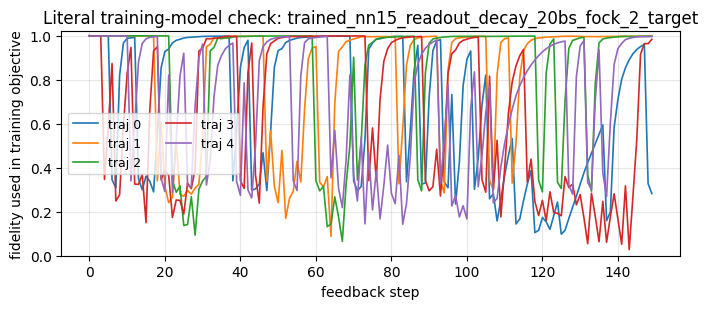

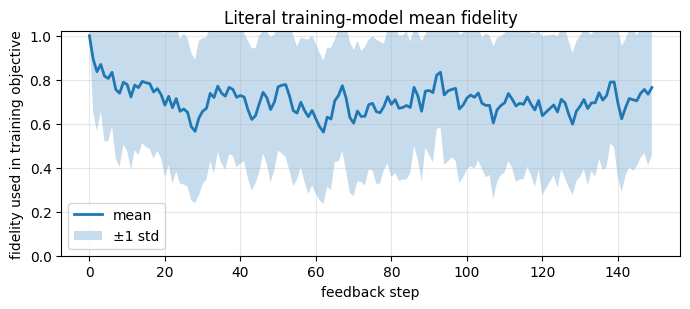

In [16]:

plt.figure(figsize=(7.0, 3.2))
for i in range(min(5, batch_size_test)):
    plt.plot(np.asarray(fids[i]), lw=1.2, label=f"traj {i}")
plt.xlabel("feedback step")
plt.ylabel("fidelity used in training objective")
plt.title(f"Literal training-model check: {trained_folder.name}")
plt.ylim(0.0, 1.02)
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.0, 3.2))
steps = np.arange(num_time_steps_test)
f_mean = np.asarray(fids).mean(axis=0)
f_std = np.asarray(fids).std(axis=0)
plt.plot(steps, f_mean, lw=2, label="mean")
plt.fill_between(steps, f_mean - f_std, f_mean + f_std, alpha=0.25, label="±1 std")
plt.xlabel("feedback step")
plt.ylabel("fidelity used in training objective")
plt.title("Literal training-model mean fidelity")
plt.ylim(0.0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## If this is still bad: scan folders and targets

If the literal training-model check is still around 2%, the model dynamics are now probably not the problem. The most likely causes are:

1. the loaded `weights.bin` is not the one that reached high fidelity;
2. the target Fock state is not the one used for that folder;
3. the folder name is misleading.

The cell below quickly tests all `trained_nn15*` folders that contain `weights.bin` for target `|1>` and `|2>`. It is disabled by default because it compiles several JAX functions.


In [17]:

RUN_FOLDER_TARGET_SCAN = False

if RUN_FOLDER_TARGET_SCAN:
    scan_results = []
    scan_steps = 50
    scan_batch = 8
    candidate_folders = [p for p in sorted(Path.cwd().glob("trained_nn15*")) if (p / "weights.bin").exists()]

    for folder in candidate_folders:
        for target_n in [1, 2]:
            print("\nTesting", folder.name, "target |{}>".format(target_n))
            psi_t = basis(N_cav, target_n)
            psi_t = psi_t / jnp.sqrt(hconj(psi_t) @ psi_t)

            key, subkey = jax.random.split(key)
            state_tmp = create_flax_state(
                subkey, rec_features, dense_features, inp_shape, learning_rate, print_summary=False
            )
            state_tmp = load_feedback_grape_weights_bin_into_flax_state(folder, state_tmp)

            test_tmp = make_test_on_batch(
                N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle,
                psi_t,
                scan_batch,
                scan_steps,
            )
            key, subkey = jax.random.split(key)
            fids_tmp, _, _ = test_tmp(subkey, state_tmp)
            score = float(fids_tmp[:, scan_steps // 2:].mean())
            final_score = float(fids_tmp[:, -1].mean())
            print("  mean last-half fidelity =", score, "final mean =", final_score)
            scan_results.append((score, final_score, folder.name, target_n))

    scan_results = sorted(scan_results, reverse=True)
    print("\nBest results:")
    for score, final_score, folder_name, target_n in scan_results[:10]:
        print(f"{score:.6f}  final={final_score:.6f}  target=|{target_n}>  folder={folder_name}")



## Optional Dynamiqs translation

Only use this after the literal training-model check above is good. This section translates the same physical model into Dynamiqs. If the literal check is high but Dynamiqs is low, the remaining mismatch is in this translation, not in the trained policy.


In [18]:

try:
    import dynamiqs as dq
    try:
        dq.set_progress_meter(False)
    except Exception:
        pass
    HAS_DYNAMIQS = True
except Exception as exc:
    HAS_DYNAMIQS = False
    print("Could not import dynamiqs:", type(exc).__name__, exc)

if HAS_DYNAMIQS:
    def qtoarray(x):
        try:
            return x.to_jax()
        except Exception:
            return jnp.asarray(np.asarray(x))

    g, e, Pg, Pe, sm, sp, sz = qubit_ops()
    I_q = identity(2)
    I_c = identity(N_cav)
    I_tot = tensor(I_q, I_c)
    a_op = tensor(I_q, destroy(N_cav))
    adag_op = hconj(a_op)
    n_phot = adag_op @ a_op
    sigz_op = tensor(sz, I_c)
    sigp_op = tensor(sp, I_c)
    sigm_op = tensor(sm, I_c)

    H_disp = (chi / 2) * n_phot @ (I_tot - sigz_op)
    H_zero = jnp.zeros_like(H_disp)

    c_ops = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)

    def _dq_options(save_states=False):
        try:
            return dq.Options(save_states=save_states, progress_meter=False, assume_hermitian=True)
        except TypeError:
            return dq.Options(progress_meter=False)

    def _dq_final_state(result):
        if hasattr(result, "final_state"):
            return qtoarray(result.final_state)
        return qtoarray(result.states[-1])

    def clean_trace(rho):
        return rho / jnp.trace(rho)

    def dynamiqs_lindblad(rho, H, jump_ops, tsave):
        result = dq.mesolve(
            dq.asqarray(H),
            [dq.asqarray(c) for c in jump_ops],
            dq.asqarray(rho),
            jnp.asarray(tsave),
            method=dq.method.Tsit5(rtol=1e-7, atol=1e-9, max_steps=1_000_000),
            options=_dq_options(save_states=False),
        )
        return clean_trace(_dq_final_state(result))

    def dynamiqs_idle_same_model(rho):
        return dynamiqs_lindblad(rho, H_zero, c_ops, jnp.array([0.0, float(t_idle)]))

    def make_dynamiqs_drive_hamiltonian_same_model(es_qub, es_cav):
        H = dq.asqarray(H_disp)
        H = H + dq.pwc(t_drive_edges, es_qub, dq.asqarray(mu_qub * sigp_op))
        H = H + dq.pwc(t_drive_edges, jnp.conj(es_qub), dq.asqarray(mu_qub * sigm_op))
        H = H + dq.pwc(t_drive_edges, jnp.conj(es_cav), dq.asqarray(mu_cav * adag_op))
        H = H + dq.pwc(t_drive_edges, es_cav, dq.asqarray(mu_cav * a_op))
        return H

    def dynamiqs_drive_same_model(rho, es_qub, es_cav):
        H = make_dynamiqs_drive_hamiltonian_same_model(es_qub, es_cav)
        return dynamiqs_lindblad(rho, H, [], t_drive_edges)

    print("Dynamiqs same-model translation defined.")


Dynamiqs same-model translation defined.


In [ ]:

# Small Dynamiqs check. Keep this small first.
RUN_DYNAMIQS_CHECK = False

if RUN_DYNAMIQS_CHECK:
    if not HAS_DYNAMIQS:
        raise RuntimeError("Dynamiqs is not available.")

    def run_one_dynamiqs_trajectory(key, num_steps=20):
        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        rho = tensor(basis(2), psi_target_cav)
        rho = rho @ hconj(rho)

        fids_dq = []
        for step in range(num_steps):
            key2, subkey = jax.random.split(key2)
            meas_out, prob, rho = measure_sz(subkey, rho)
            fids_dq.append(float(fidelity_cav(rho)))

            rho = dynamiqs_idle_same_model(rho)

            rnn_inp = jnp.array([meas_out], dtype=float)
            carry, ctrl_coeffs = apply_nn(flax_state, flax_state.params, carry, rnn_inp)
            es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
            rho = dynamiqs_drive_same_model(rho, es_qub, es_cav)

            print(f"step {step:3d}: F_obj={fids_dq[-1]:.6f} m={float(meas_out):+g} p={float(prob):.6f}")

        return np.asarray(fids_dq)

    key, subkey = jax.random.split(key)
    fids_dq = run_one_dynamiqs_trajectory(subkey, num_steps=20)
    print("Dynamiqs mean fidelity:", float(fids_dq.mean()))


ValueError: None is not a valid value for jnp.array


## Interpretation

- If the literal training-model check is high, the trained NN and `weights.bin` are loaded correctly.
- If the literal training-model check is still around 2%, run the folder/target scan. The model folder or target is probably wrong.
- If the literal check is high but the Dynamiqs check is low, then the mismatch is in the Dynamiqs Hamiltonian/control convention, not in the NN.
